ПОСТАНОВА ЗАДАЧІ

1. Завантажте набір даних про дитячі імена США з веб-сайту kaggle.com (https://www.kaggle.com/kaggle/us-baby-names?select=NationalNames.csv)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження набору даних
df = pd.read_csv('NationalNames.csv')

Варіант 2

3. Отримайте імена стовпців набору даних

In [6]:
columns_names = df.columns
columns_names

Index(['Id', 'Name', 'Year', 'Gender', 'Count'], dtype='str')

4. Отримайте загальну інформацію про дані у наборі даних.

In [7]:
general_info = df.describe()
general_info

,Id,Year,Count
count,1.825433e+06,1.825433e+06,1.825433e+06
mean,9.127170e+05,1.972620e+03,1.846879e+02
std,5.269573e+05,3.352891e+01,1.566711e+03
min,1.000000e+00,1.880000e+03,5.000000e+00
25%,4.563590e+05,1.949000e+03,7.000000e+00
50%,9.127170e+05,1.982000e+03,1.200000e+01
75%,1.369075e+06,2.001000e+03,3.200000e+01
max,1.825433e+06,2.014000e+03,9.968000e+04


5. Знайти кількість унікальних імен у наборі даних

In [8]:
unique_names_count = df['Name'].nunique()
unique_names_count

93889

8. Знайдіть найпопулярніше ім’я за результатами одного року (ім’я, для
якого Count максимальне)

In [9]:
max_count_idx = df['Count'].idxmax()
popular_name = df.loc[max_count_idx, 'Name']
popular_year = df.loc[max_count_idx, 'Year']

print(f"The name is '{popular_name}' in {popular_year}")

The name is 'Linda' in 1947


9. Підрахуйте кількість записів, для яких Count - мінімальне у наборі.

In [10]:
min_count = df['Count'].min()
min_records_count = len(df[df['Count'] == min_count])
min_records_count

254615

11. Знайдіть рік із найбільшою кількістю унікальних імен.

In [11]:
# Рахуємо унікальні імена по роках
unique_names_by_year = df.groupby('Year')['Name'].nunique()

year_max_unique = unique_names_by_year.idxmax()
count_max_unique = unique_names_by_year.max()

result_11 = pd.DataFrame({'Name': [count_max_unique]}, index=[year_max_unique])
result_11.index.name = 'Year'
result_11

,Name
Year,
2008,32488


12. Знайдіть найпопулярніше ім’я в році з найбільшою кількістю
унікальних імен (тобто у 2008 році)

In [12]:
df_2008 = df[df['Year'] == 2008]
most_popular_2008 = df_2008.groupby('Name')['Count'].sum().idxmax()
most_popular_2008

'Jacob'

13. Знайдіть рік, коли ім’я “Jacob” було найпопулярнішим серед
жіночих імен

In [13]:
jacob_female = df[(df['Name'] == 'Jacob') & (df['Gender'] == 'F')]
jacob_female_max = jacob_female.sort_values(by='Count', ascending=False).head(1)
jacob_female_max

,Id,Name,Year,Gender,Count
1455556,1455557,Jacob,2004,F,171


14. Знайти рік із найбільшою кількістю гендерно нейтральних імен
(однакові чоловічі та жіночі імена)

In [14]:
# Кількість статей для кожного імені в кожному році
genders_per_name_year = df.groupby(['Year', 'Name'])['Gender'].nunique()

# Фільтруємо лише ті, де є 2 статі
neutral_names_by_year = genders_per_name_year[genders_per_name_year == 2].groupby('Year').count()

year_max_neutral = neutral_names_by_year.idxmax()
count_max_neutral = neutral_names_by_year.max()

result_14 = pd.DataFrame({'Gender_neutral_names': [count_max_neutral]}, index=[year_max_neutral])
result_14.index.name = 'Year'
result_14

,Gender_neutral_names
Year,
2008,2557


16. Знайдіть рік, коли народилося найбільше дітей

In [15]:
most_births_year = df.groupby('Year')['Count'].sum().idxmax()
most_births_year

np.int64(1957)

17. Знайдіть кількість дівчаток та хлопчиків, які народились кожного року

In [16]:
births_by_year_gender = df.groupby(['Year', 'Gender'])['Count'].sum().unstack()
births_by_year_gender.head()

Gender,F,M
Year,,
1880,90993,110491
1881,91954,100745
1882,107850,113688
1883,112321,104629
1884,129022,114445


18. Підрахуйте кількість років, коли дівчаток народжувалось більше, ніж хлопчиків.

In [17]:
years_more_girls = len(births_by_year_gender[births_by_year_gender['F'] > births_by_year_gender['M']])
years_more_girls

54

19. Накресліть графік загальної кількості народжень хлопчиків та дівчаток на рік.

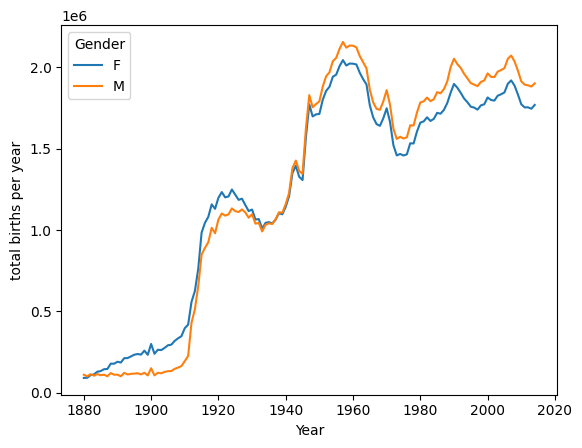

In [18]:
ax = births_by_year_gender.plot(title='')
ax.set_ylabel("total births per year")
plt.show()

20. Підрахуйте кількість гендерно-нейтральних імен (однакових для дівчат та хлопців)

In [19]:
genders_per_name_total = df.groupby('Name')['Gender'].nunique()
total_neutral_names = len(genders_per_name_total[genders_per_name_total == 2])
total_neutral_names

10221

22. Підрахуйте скільки років проводилось спостереження

In [20]:
observation_years = df['Year'].nunique()
print(f"Спостереження проводилось {observation_years} років")

Спостереження проводилось 135 років


23. Знати найпопулярніші гендерно-нейтральні імена (ті, що присутні кожного року)

In [21]:
# Знаходимо імена, присутні у кожному році
years_total = df['Year'].nunique()
years_per_name = df.groupby('Name')['Year'].nunique()
names_every_year = years_per_name[years_per_name == years_total].index

# Знаходимо гендерно-нейтральні імена (ті, що мають дві статі)
neutral_names_list = genders_per_name_total[genders_per_name_total == 2].index

# Знаходимо спільні імена (гендерно нейтральні ТА присутні кожного року)
target_names = names_every_year.intersection(neutral_names_list)

# Рахуємо їх загальну популярність та беремо топ
popular_neutral_every_year = df[df['Name'].isin(target_names)].groupby('Name')['Count'].sum().sort_values(ascending=False)

# Створюємо DataFrame у форматі, як в умові
result_23 = pd.DataFrame(popular_neutral_every_year.head(16).index)
result_23

,Name
0,James
1,John
2,Robert
3,Michael
4,Mary
5,William
6,David
7,Joseph
8,Richard
9,Charles


24. Знайти найпопулярніше серед непопулярних імен (непопулярне ім’я, яким називали дітей найбільшу кількість разів )

In [22]:
min_records = df[df['Count'] == df['Count'].min()]
most_popular_unpopular = min_records['Name'].value_counts().head(1)

unpop_name = most_popular_unpopular.index[0]
unpop_count = most_popular_unpopular.values[0]

print(f"Найбільш популярне із непопулярних імен - це {unpop_name}. Ним називали {unpop_count} рази(ів).")

Найбільш популярне із непопулярних імен - це Celester. Ним називали 32 рази(ів).


27. Знайти найпопулярніші імена в кожному році.

In [23]:
most_popular_by_year = df.groupby('Year').apply(lambda x: x.loc[x['Count'].idxmax()])
result_27 = most_popular_by_year[['Name', 'Count']]
result_27

,Name,Count
Year,,
1880,John,9655
1881,John,8769
1882,John,9557
1883,John,8894
1884,John,9388
...,...,...
2010,Isabella,22883
2011,Sophia,21816
2012,Sophia,22267
